# Final Submission V2: Portable Music Genre Classification on GTZAN and Suno

This notebook reproduces the final project pipeline from raw audio folders and is designed to travel cleanly to another computer.

It keeps the same analysis flow as the original final notebook:

1. load raw audio from `human_music/` and `ai_music/`,
2. build MFCC segment features from each track,
3. train the parent-style CNN on human music,
4. evaluate the same CNN on AI music,
5. compare that baseline with MFCC-statistics classical ML models,
6. save the final tables and confusion matrix under `artifacts/final_submission_v2/`.

The only manual step is setting the dataset inputs in the next cell if your folders are not already named `human_music/` and `ai_music/`.


## 1. Notebook Inputs

Update the next cell only if your dataset folders are somewhere else.

Accepted values for each input:

- a direct path to the dataset root with the ten genre folders,
- a parent folder that contains `human_music/`, `ai_music/`, or `genres_original/`,
- or `None` to let the notebook auto-discover the folders from the current project.


In [12]:
# Optional overrides for another computer.
# Examples:
# HUMAN_DATA_INPUT = "/absolute/path/to/human_music"
# AI_DATA_INPUT = "/absolute/path/to/ai_music"
# PROJECT_ROOT_INPUT = "/absolute/path/to/ds_340_final_report"

PROJECT_ROOT_INPUT = None
HUMAN_DATA_INPUT = "human_music"
AI_DATA_INPUT = "ai_music"
OUTPUT_SUBDIR = "artifacts/final_submission_v2"


## Runtime Dependencies

This notebook can bootstrap its runtime packages inside the active Jupyter kernel.

If you already ran `pip install -r requirements.txt`, this cell will simply confirm that everything is ready. If not, it will install the missing packages needed by the notebook before the main imports run.


In [13]:
import importlib
import importlib.util
import subprocess
import sys

RUNTIME_DEPENDENCIES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "librosa": "librosa",
    "soundfile": "soundfile",
    "tensorflow": "tensorflow",
    "sklearn": "scikit-learn",
    "IPython": "ipython",
}

missing_packages = [
    package_name
    for module_name, package_name in RUNTIME_DEPENDENCIES.items()
    if importlib.util.find_spec(module_name) is None
]

print("Python executable:", sys.executable)
if missing_packages:
    print("Installing missing runtime packages:", ", ".join(missing_packages))
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
        importlib.invalidate_caches()
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(
            "Automatic dependency installation failed. Run `pip install -r requirements.txt` "
            "in the same environment as this notebook, then rerun all cells."
        ) from exc
else:
    print("All runtime packages are already installed.")


Python executable: /Users/mingoosim/miniconda3/bin/python
All runtime packages are already installed.


## 2. Setup And Path Resolution

This section makes the notebook portable by:

- using `tf.keras` instead of a separate standalone Keras import,
- searching for the project root and dataset folders more flexibly,
- allowing either repo-local folders or absolute dataset paths,
- writing all outputs into a dedicated artifact folder.


In [14]:
import json
import math
import os
import platform
import warnings
from collections import Counter
from pathlib import Path

warnings.filterwarnings("ignore", message="PySoundFile failed. Trying audioread instead.")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*audioread_load.*")
warnings.filterwarnings("ignore", message="IProgress not found.*")

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from tensorflow import keras

GENRES = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock",
]
SUPPORTED_AUDIO_EXTENSIONS = {".wav", ".mp3", ".flac", ".ogg", ".m4a", ".aac"}

SAMPLE_RATE = 22050
TRACK_DURATION = 30
SAMPLES_PER_TRACK = SAMPLE_RATE * TRACK_DURATION
NUM_MFCC = 13
N_FFT = 2048
HOP_LENGTH = 512
NUM_SEGMENTS = 10
EXPECTED_FRAMES = math.ceil((SAMPLES_PER_TRACK // NUM_SEGMENTS) / HOP_LENGTH)
TEST_SIZE = 0.3
LEARNING_RATE = 1e-4
EPOCHS = int(os.environ.get("FINAL_SUBMISSION_EPOCHS", "50"))
BATCH_SIZE = int(os.environ.get("FINAL_SUBMISSION_BATCH_SIZE", "32"))
SEED = int(os.environ.get("FINAL_SUBMISSION_SEED", "42"))


def has_expected_genre_layout(folder_path: Path) -> bool:
    return folder_path.exists() and folder_path.is_dir() and all((folder_path / genre).is_dir() for genre in GENRES)


def dedupe_paths(paths):
    seen = set()
    ordered = []
    for path in paths:
        try:
            resolved = Path(path).expanduser().resolve()
        except Exception:
            resolved = Path(path).expanduser()
        key = str(resolved)
        if key not in seen:
            seen.add(key)
            ordered.append(resolved)
    return ordered


def candidate_input_roots(user_value, project_root: Path):
    candidates = []
    if user_value is not None:
        raw = Path(user_value).expanduser()
        candidates.append(raw)
        if not raw.is_absolute():
            candidates.append(project_root / raw)
            candidates.append(Path.cwd() / raw)
    else:
        candidates.extend([project_root, Path.cwd()])
    return dedupe_paths(candidates)


def resolve_project_root(project_root_input=None) -> Path:
    markers = ["README.md", "prepare_ai_music.py"]
    candidates = []
    if project_root_input is not None:
        raw = Path(project_root_input).expanduser()
        candidates.append(raw)
        if not raw.is_absolute():
            candidates.append(Path.cwd() / raw)
    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])
    for candidate in dedupe_paths(candidates):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    return cwd


def resolve_human_data_root(project_root: Path, human_data_input=None) -> Path:
    candidates = []
    for root in candidate_input_roots(human_data_input, project_root):
        candidates.extend(
            [
                root,
                root / "human_music",
                root / "genres_original",
                root / "Data" / "genres_original",
                root / "human_music" / "genres_original",
                root / "human_music" / "Data" / "genres_original",
                root / "data" / "genres_original",
            ]
        )
    for candidate in dedupe_paths(candidates):
        if has_expected_genre_layout(candidate):
            return candidate
    searched = "\\n".join(f"- {path}" for path in dedupe_paths(candidates))
    raise FileNotFoundError(
        "Could not find the human music dataset. Set HUMAN_DATA_INPUT to the GTZAN folder or its parent.\\n"
        f"Searched:\\n{searched}"
    )


def resolve_ai_data_root(project_root: Path, ai_data_input=None) -> Path:
    candidates = []
    for root in candidate_input_roots(ai_data_input, project_root):
        candidates.extend(
            [
                root,
                root / "ai_music",
                root / "data" / "ai_music",
            ]
        )
    for candidate in dedupe_paths(candidates):
        if has_expected_genre_layout(candidate):
            return candidate
    searched = "\\n".join(f"- {path}" for path in dedupe_paths(candidates))
    raise FileNotFoundError(
        "Could not find the AI music dataset. Set AI_DATA_INPUT to the ai_music folder or its parent.\\n"
        f"Searched:\\n{searched}"
    )


PROJECT_ROOT = resolve_project_root(PROJECT_ROOT_INPUT)
ARTIFACT_DIR = (PROJECT_ROOT / OUTPUT_SUBDIR).resolve()
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MPLCONFIG_DIR = ARTIFACT_DIR / ".mplconfig"
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR))
os.environ.setdefault("KERAS_BACKEND", "tensorflow")

HUMAN_DATA_ROOT = resolve_human_data_root(PROJECT_ROOT, HUMAN_DATA_INPUT)
AI_DATA_ROOT = resolve_ai_data_root(PROJECT_ROOT, AI_DATA_INPUT)

FINAL_COMPARISON_CSV = ARTIFACT_DIR / "final_method_comparison.csv"
CNN_AI_TRACK_RESULTS_CSV = ARTIFACT_DIR / "cnn_ai_track_results.csv"
ML_METHOD_COMPARISON_CSV = ARTIFACT_DIR / "mfcc_stats_method_comparison.csv"
ML_TRACK_RESULTS_CSV = ARTIFACT_DIR / "mfcc_stats_track_results.csv"
FINAL_SUMMARY_JSON = ARTIFACT_DIR / "final_summary.json"
AI_TRACK_CONFUSION_MATRIX_PNG = ARTIFACT_DIR / "final_ai_track_confusion_matrix.png"
TRAINING_HISTORY_CSV = ARTIFACT_DIR / "cnn_training_history.csv"

keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("Project root:", PROJECT_ROOT)
print("Human dataset root:", HUMAN_DATA_ROOT)
print("AI dataset root:", AI_DATA_ROOT)
print("Output folder:", ARTIFACT_DIR)
print("Epochs:", EPOCHS, "Batch size:", BATCH_SIZE, "Seed:", SEED)


Python: 3.12.9
TensorFlow: 2.21.0
Project root: /Users/mingoosim/Desktop/DS340/Proejct
Human dataset root: /Users/mingoosim/Desktop/DS340/Proejct/human_music
AI dataset root: /Users/mingoosim/Desktop/DS340/Proejct/ai_music
Output folder: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/final_submission_v2
Epochs: 50 Batch size: 32 Seed: 42


### Visualization Helpers

The following helper functions keep the visual outputs consistent across the notebook and save each figure into the artifact folder for the final report.


In [15]:
def save_figure(fig, output_path: Path):
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    return output_path


def annotate_bars(ax, fmt="{:.3f}"):
    for container in ax.containers:
        labels = []
        for bar in container:
            value = bar.get_height()
            labels.append(fmt.format(value) if np.isfinite(value) else "")
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)


def plot_labeled_confusion_matrix(matrix, labels, title, output_path: Path, figsize=(8, 6), cmap="Blues"):
    fig, ax = plt.subplots(figsize=figsize)
    image = ax.imshow(matrix, cmap=cmap)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    threshold = matrix.max() / 2 if matrix.size else 0
    for row_index in range(matrix.shape[0]):
        for col_index in range(matrix.shape[1]):
            color = "white" if matrix[row_index, col_index] > threshold else "black"
            ax.text(col_index, row_index, matrix[row_index, col_index], ha="center", va="center", color=color)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    save_figure(fig, output_path)
    plt.show()
    return fig, ax


def apply_metric_axis_style(ax, title, ylabel):
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.25)


## 3. Build MFCC Features From The Audio Folders

The preprocessing matches the original final notebook:

- load audio at 22050 Hz,
- keep exactly the first 30 seconds,
- pad shorter clips to 30 seconds,
- split each track into 10 equal segments,
- extract 13 MFCC coefficients per segment.


In [16]:
def list_audio_files(folder_path: Path):
    return sorted(
        path for path in folder_path.rglob("*")
        if path.is_file() and path.suffix.lower() in SUPPORTED_AUDIO_EXTENSIONS
    )


def standardize_track_length(signal: np.ndarray) -> np.ndarray:
    if len(signal) < SAMPLES_PER_TRACK:
        signal = np.pad(signal, (0, SAMPLES_PER_TRACK - len(signal)))
    else:
        signal = signal[:SAMPLES_PER_TRACK]
    return signal


def standardize_mfcc_frames(mfcc: np.ndarray) -> np.ndarray:
    if len(mfcc) < EXPECTED_FRAMES:
        pad_rows = EXPECTED_FRAMES - len(mfcc)
        mfcc = np.pad(mfcc, ((0, pad_rows), (0, 0)), mode="edge")
    elif len(mfcc) > EXPECTED_FRAMES:
        mfcc = mfcc[:EXPECTED_FRAMES]
    return mfcc.astype(np.float32)


def extract_mfcc_segments_from_file(file_path: Path):
    signal, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
    signal = standardize_track_length(signal)
    samples_per_segment = SAMPLES_PER_TRACK // NUM_SEGMENTS
    segments = []

    for segment_index in range(NUM_SEGMENTS):
        start_sample = samples_per_segment * segment_index
        finish_sample = start_sample + samples_per_segment
        segment_signal = signal[start_sample:finish_sample]
        mfcc = librosa.feature.mfcc(
            y=segment_signal,
            sr=sr,
            n_mfcc=NUM_MFCC,
            n_fft=N_FFT,
            hop_length=HOP_LENGTH,
        ).T
        segments.append(standardize_mfcc_frames(mfcc))
    return segments


def load_segment_dataset(dataset_root: Path, label_names):
    all_mfcc = []
    all_labels = []
    track_keys = []
    track_ids = []
    file_paths = []
    genre_track_counts = {}

    for label_id, genre_name in enumerate(label_names):
        genre_dir = dataset_root / genre_name
        audio_files = list_audio_files(genre_dir)
        genre_track_counts[genre_name] = len(audio_files)
        if not audio_files:
            raise FileNotFoundError(f"No audio files found in {genre_dir}")

        for audio_file in audio_files:
            segments = extract_mfcc_segments_from_file(audio_file)
            track_key = str(audio_file.relative_to(dataset_root))
            track_id = audio_file.stem
            for mfcc in segments:
                all_mfcc.append(mfcc)
                all_labels.append(label_id)
                track_keys.append(track_key)
                track_ids.append(track_id)
                file_paths.append(str(audio_file))

    return {
        "X": np.asarray(all_mfcc, dtype=np.float32),
        "y": np.asarray(all_labels, dtype=np.int64),
        "track_keys": track_keys,
        "track_ids": track_ids,
        "file_paths": file_paths,
        "genre_track_counts": genre_track_counts,
    }


human_data = load_segment_dataset(HUMAN_DATA_ROOT, GENRES)
ai_data = load_segment_dataset(AI_DATA_ROOT, GENRES)

X_human = human_data["X"]
y_human = human_data["y"]
X_ai = ai_data["X"]
y_ai = ai_data["y"]

print("Human track counts:", human_data["genre_track_counts"])
print("AI track counts:", ai_data["genre_track_counts"])
print("Human MFCC shape:", X_human.shape)
print("AI MFCC shape:", X_ai.shape)


Human track counts: {'blues': 100, 'classical': 100, 'country': 100, 'disco': 100, 'hiphop': 100, 'jazz': 99, 'metal': 100, 'pop': 100, 'reggae': 100, 'rock': 100}
AI track counts: {'blues': 30, 'classical': 28, 'country': 30, 'disco': 30, 'hiphop': 30, 'jazz': 30, 'metal': 30, 'pop': 30, 'reggae': 30, 'rock': 30}
Human MFCC shape: (9990, 130, 13)
AI MFCC shape: (2980, 130, 13)


### Visual Evidence: Dataset Balance And Sample MFCCs

Before training, these plots confirm that the notebook is reading the expected number of tracks from each genre and that the extracted MFCC tensors look structurally reasonable for both datasets.


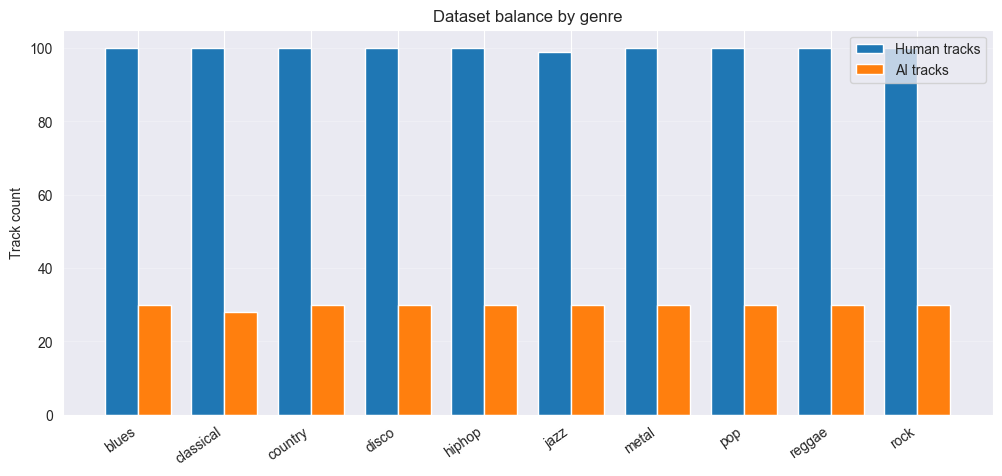

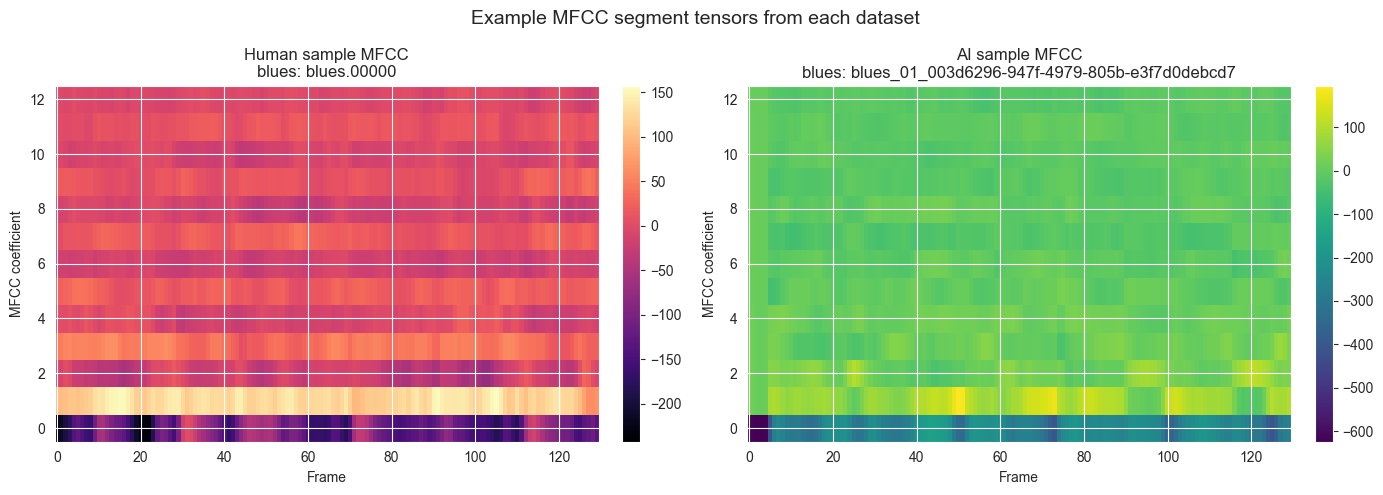

Saved dataset count plot: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/final_submission_v2/dataset_track_counts.png
Saved sample MFCC heatmaps: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/final_submission_v2/sample_mfcc_heatmaps.png


In [17]:
DATASET_TRACK_COUNTS_PNG = ARTIFACT_DIR / "dataset_track_counts.png"
SAMPLE_MFCC_HEATMAPS_PNG = ARTIFACT_DIR / "sample_mfcc_heatmaps.png"

dataset_counts_df = pd.DataFrame(
    {
        "genre": GENRES,
        "human_tracks": [human_data["genre_track_counts"][genre] for genre in GENRES],
        "ai_tracks": [ai_data["genre_track_counts"][genre] for genre in GENRES],
    }
)

genre_positions = np.arange(len(GENRES))
bar_width = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(genre_positions - bar_width / 2, dataset_counts_df["human_tracks"], width=bar_width, label="Human tracks")
ax.bar(genre_positions + bar_width / 2, dataset_counts_df["ai_tracks"], width=bar_width, label="AI tracks")
ax.set_xticks(genre_positions)
ax.set_xticklabels(GENRES, rotation=35, ha="right")
ax.set_ylabel("Track count")
ax.set_title("Dataset balance by genre")
ax.legend()
ax.grid(axis="y", alpha=0.25)
save_figure(fig, DATASET_TRACK_COUNTS_PNG)
plt.show()

human_sample_index = 0
ai_sample_index = 0
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
human_image = axes[0].imshow(X_human[human_sample_index].T, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title(
    f"Human sample MFCC\n{GENRES[y_human[human_sample_index]]}: {human_data['track_ids'][human_sample_index]}"
)
axes[0].set_xlabel("Frame")
axes[0].set_ylabel("MFCC coefficient")
fig.colorbar(human_image, ax=axes[0], fraction=0.046, pad=0.04)

ai_image = axes[1].imshow(X_ai[ai_sample_index].T, aspect="auto", origin="lower", cmap="viridis")
axes[1].set_title(
    f"AI sample MFCC\n{GENRES[y_ai[ai_sample_index]]}: {ai_data['track_ids'][ai_sample_index]}"
)
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("MFCC coefficient")
fig.colorbar(ai_image, ax=axes[1], fraction=0.046, pad=0.04)

fig.suptitle("Example MFCC segment tensors from each dataset", fontsize=14)
fig.tight_layout()
save_figure(fig, SAMPLE_MFCC_HEATMAPS_PNG)
plt.show()

print("Saved dataset count plot:", DATASET_TRACK_COUNTS_PNG)
print("Saved sample MFCC heatmaps:", SAMPLE_MFCC_HEATMAPS_PNG)


## 4. Parent-Style CNN Baseline On Human Music

This matches the final notebook architecture: three convolution blocks, batch normalization, a dense layer, dropout, and a softmax output layer.


In [18]:
def build_parent_style_cnn(input_shape, num_classes):
    model = keras.Sequential(name="parent_style_cnn")
    model.add(keras.layers.Input(shape=input_shape))
    model.add(keras.layers.Conv2D(32, (3, 3), activation="relu"))
    model.add(keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding="same"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Conv2D(32, (3, 3), activation="relu"))
    model.add(keras.layers.MaxPooling2D((3, 3), strides=(2, 2), padding="same"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Conv2D(32, (2, 2), activation="relu"))
    model.add(keras.layers.MaxPooling2D((2, 2), strides=(2, 2), padding="same"))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(64, activation="relu"))
    model.add(keras.layers.Dropout(0.3))
    model.add(keras.layers.Dense(num_classes, activation="softmax"))
    return model


X_train, X_test, y_train, y_test = train_test_split(
    X_human,
    y_human,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y_human,
)

X_train_cnn = X_train[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]
X_ai_cnn = X_ai[..., np.newaxis]

cnn_model = build_parent_style_cnn(X_train_cnn.shape[1:], len(GENRES))
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = cnn_model.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

pd.DataFrame(history.history).to_csv(TRAINING_HISTORY_CSV, index=False)

cnn_test_loss, cnn_human_accuracy = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
cnn_human_pred = cnn_model.predict(X_test_cnn, verbose=0).argmax(axis=1)
cnn_human_macro_f1 = f1_score(
    y_test,
    cnn_human_pred,
    average="macro",
    labels=list(range(len(GENRES))),
    zero_division=0,
)

print(f"Human CNN accuracy: {cnn_human_accuracy:.4f}")
print(f"Human CNN macro F1: {cnn_human_macro_f1:.4f}")


Epoch 1/50


E0000 00:00:1777005706.498228 16537974 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.2485 - loss: 2.2835 - val_accuracy: 0.3747 - val_loss: 1.7802
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3767 - loss: 1.7805 - val_accuracy: 0.4705 - val_loss: 1.5042
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4359 - loss: 1.5882 - val_accuracy: 0.5072 - val_loss: 1.3782
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4786 - loss: 1.4559 - val_accuracy: 0.5415 - val_loss: 1.2881
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5199 - loss: 1.3541 - val_accuracy: 0.5586 - val_loss: 1.2325
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.5475 - loss: 1.2863 - val_accuracy: 0.5792 - val_loss: 1.1929
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5700 - loss: 1.2173 - val_accuracy: 0.5886 - val_loss: 1.1586
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.5879 - loss: 1.1688 - val_accuracy: 0.601

E0000 00:00:1777005888.650284 16537974 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


Human CNN accuracy: 0.7281
Human CNN macro F1: 0.7245


### Visual Evidence: CNN Training Behavior On Human Music

These plots show how the parent-style CNN learned on GTZAN human music, including both the training trajectory and the held-out human confusion matrix.


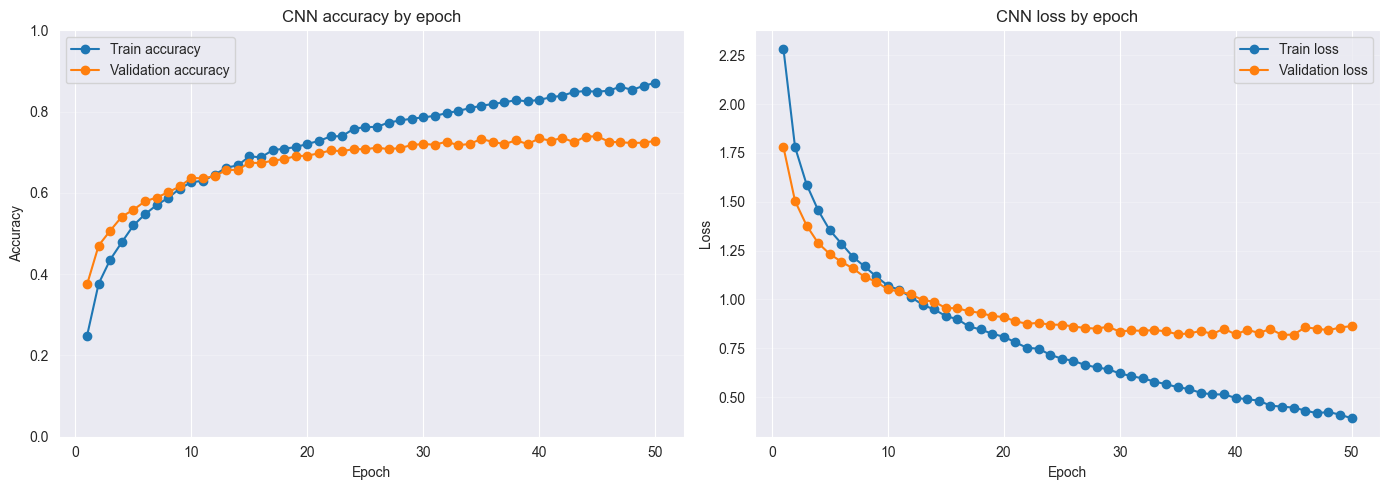

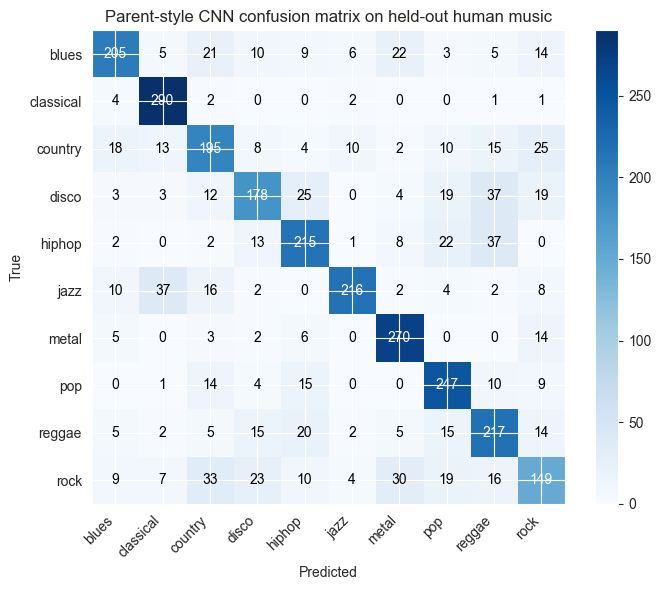

Saved CNN training curves: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/final_submission_v2/cnn_training_curves.png
Saved human confusion matrix: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/final_submission_v2/cnn_human_confusion_matrix.png


In [19]:
CNN_TRAINING_CURVES_PNG = ARTIFACT_DIR / "cnn_training_curves.png"
CNN_HUMAN_CONFUSION_MATRIX_PNG = ARTIFACT_DIR / "cnn_human_confusion_matrix.png"

history_df = pd.DataFrame(history.history)
epochs_axis = np.arange(1, len(history_df) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_axis, history_df["accuracy"], marker="o", label="Train accuracy")
axes[0].plot(epochs_axis, history_df["val_accuracy"], marker="o", label="Validation accuracy")
apply_metric_axis_style(axes[0], "CNN accuracy by epoch", "Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_axis, history_df["loss"], marker="o", label="Train loss")
axes[1].plot(epochs_axis, history_df["val_loss"], marker="o", label="Validation loss")
axes[1].set_title("CNN loss by epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend()

fig.tight_layout()
save_figure(fig, CNN_TRAINING_CURVES_PNG)
plt.show()

cnn_human_cm = confusion_matrix(y_test, cnn_human_pred, labels=list(range(len(GENRES))))
plot_labeled_confusion_matrix(
    cnn_human_cm,
    GENRES,
    title="Parent-style CNN confusion matrix on held-out human music",
    output_path=CNN_HUMAN_CONFUSION_MATRIX_PNG,
)

print("Saved CNN training curves:", CNN_TRAINING_CURVES_PNG)
print("Saved human confusion matrix:", CNN_HUMAN_CONFUSION_MATRIX_PNG)


## 5. Apply The CNN Baseline To AI Music

AI results are reported at both the segment level and the track level using majority vote across the 10 MFCC segments from each track.


In [20]:
cnn_ai_probs = cnn_model.predict(X_ai_cnn, verbose=0)
cnn_ai_segment_pred = cnn_ai_probs.argmax(axis=1)

cnn_ai_segment_accuracy = accuracy_score(y_ai, cnn_ai_segment_pred)
cnn_ai_segment_macro_f1 = f1_score(
    y_ai,
    cnn_ai_segment_pred,
    average="macro",
    labels=list(range(len(GENRES))),
    zero_division=0,
)

cnn_ai_segment_df = pd.DataFrame(
    {
        "track_key": ai_data["track_keys"],
        "track_id": ai_data["track_ids"],
        "true_label_id": y_ai,
        "pred_label_id": cnn_ai_segment_pred,
        "true_label": [GENRES[idx] for idx in y_ai],
        "pred_label": [GENRES[idx] for idx in cnn_ai_segment_pred],
        "confidence": cnn_ai_probs.max(axis=1),
    }
)

cnn_ai_track_df = (
    cnn_ai_segment_df.groupby(["track_key", "track_id", "true_label"], as_index=False)
    .agg(
        true_label_id=("true_label_id", "first"),
        pred_label_id=("pred_label_id", lambda series: Counter(series).most_common(1)[0][0]),
        num_segments=("pred_label_id", "size"),
        mean_confidence=("confidence", "mean"),
    )
)
cnn_ai_track_df["pred_label"] = cnn_ai_track_df["pred_label_id"].map(lambda idx: GENRES[idx])
cnn_ai_track_df.to_csv(CNN_AI_TRACK_RESULTS_CSV, index=False)

cnn_ai_track_accuracy = accuracy_score(cnn_ai_track_df["true_label_id"], cnn_ai_track_df["pred_label_id"])
cnn_ai_track_macro_f1 = f1_score(
    cnn_ai_track_df["true_label_id"],
    cnn_ai_track_df["pred_label_id"],
    average="macro",
    labels=list(range(len(GENRES))),
    zero_division=0,
)

print(f"AI CNN segment accuracy: {cnn_ai_segment_accuracy:.4f}")
print(f"AI CNN segment macro F1: {cnn_ai_segment_macro_f1:.4f}")
print(f"AI CNN track accuracy: {cnn_ai_track_accuracy:.4f}")
print(f"AI CNN track macro F1: {cnn_ai_track_macro_f1:.4f}")


E0000 00:00:1777005913.409533 16537974 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


AI CNN segment accuracy: 0.2232
AI CNN segment macro F1: 0.1951
AI CNN track accuracy: 0.2416
AI CNN track macro F1: 0.1882


### Visual Evidence: CNN Transfer Performance On AI Music

This checkpoint makes the domain-transfer gap visible by showing the AI track-level confusion matrix and the CNN's per-genre track accuracy on the AI dataset.


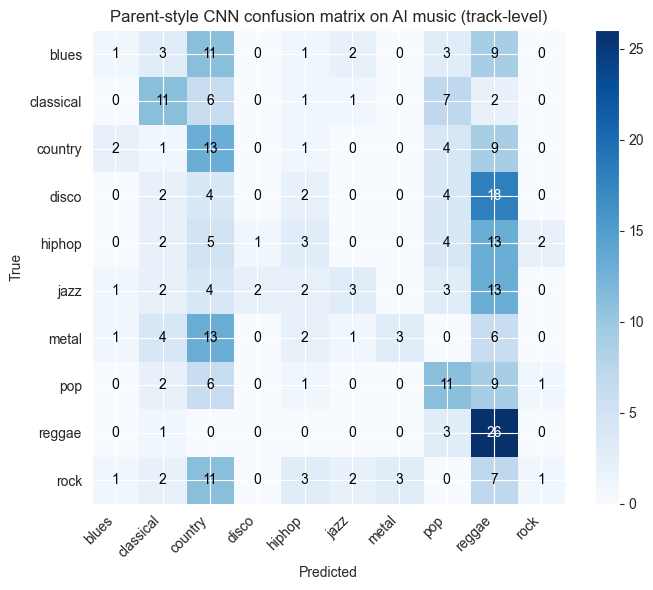

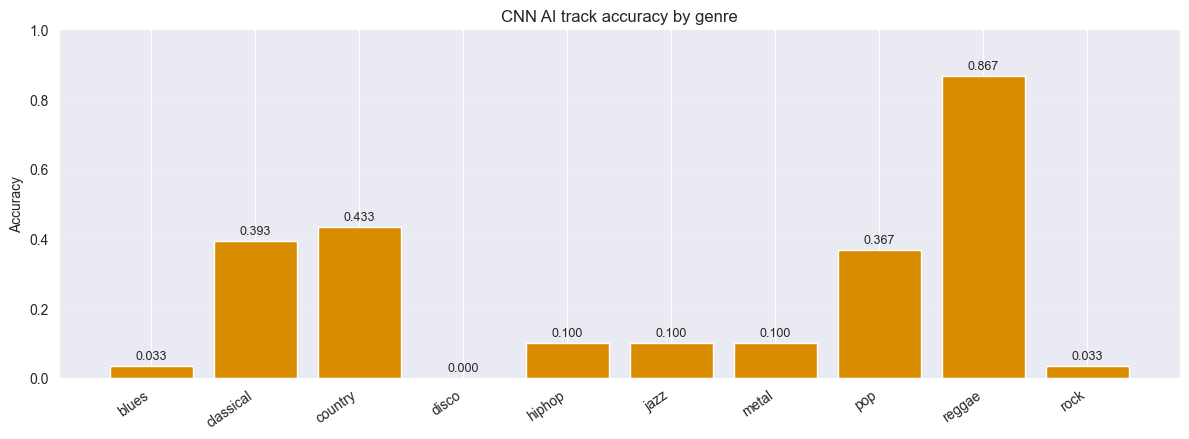

Saved AI CNN confusion matrix: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/final_submission_v2/cnn_ai_track_confusion_matrix.png
Saved AI per-genre accuracy plot: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/final_submission_v2/cnn_ai_track_accuracy_by_genre.png


In [21]:
CNN_AI_TRACK_CONFUSION_MATRIX_PNG = ARTIFACT_DIR / "cnn_ai_track_confusion_matrix.png"
CNN_AI_TRACK_ACCURACY_BY_GENRE_PNG = ARTIFACT_DIR / "cnn_ai_track_accuracy_by_genre.png"

cnn_ai_track_cm = confusion_matrix(
    cnn_ai_track_df["true_label_id"],
    cnn_ai_track_df["pred_label_id"],
    labels=list(range(len(GENRES))),
)
plot_labeled_confusion_matrix(
    cnn_ai_track_cm,
    GENRES,
    title="Parent-style CNN confusion matrix on AI music (track-level)",
    output_path=CNN_AI_TRACK_CONFUSION_MATRIX_PNG,
)

genre_track_accuracy = (
    cnn_ai_track_df.assign(correct=lambda frame: frame["true_label_id"] == frame["pred_label_id"])
    .groupby("true_label", sort=False)["correct"]
    .mean()
    .reindex(GENRES)
)
positions = np.arange(len(GENRES))
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(positions, genre_track_accuracy.values, color="#d98c00")
ax.set_xticks(positions)
ax.set_xticklabels(GENRES, rotation=35, ha="right")
apply_metric_axis_style(ax, "CNN AI track accuracy by genre", "Accuracy")
annotate_bars(ax)
fig.tight_layout()
save_figure(fig, CNN_AI_TRACK_ACCURACY_BY_GENRE_PNG)
plt.show()

print("Saved AI CNN confusion matrix:", CNN_AI_TRACK_CONFUSION_MATRIX_PNG)
print("Saved AI per-genre accuracy plot:", CNN_AI_TRACK_ACCURACY_BY_GENRE_PNG)


## 6. Final Method: MFCC Statistics With Classical ML

Each segment is converted to a compact 104-dimensional feature vector built from MFCC summary statistics and delta-MFCC summary statistics. The classical models are then trained on human-music segments and evaluated on AI music in the same way as the original final notebook.


In [22]:
def build_mfcc_statistics_features(mfcc_tensor):
    mfcc_array = np.asarray(mfcc_tensor, dtype=np.float32)
    if mfcc_array.ndim == 4:
        mfcc_array = mfcc_array[..., 0]
    deltas = np.diff(mfcc_array, axis=1)
    feature_blocks = [
        mfcc_array.mean(axis=1),
        mfcc_array.std(axis=1),
        np.percentile(mfcc_array, 25, axis=1),
        np.percentile(mfcc_array, 75, axis=1),
        mfcc_array.min(axis=1),
        mfcc_array.max(axis=1),
        deltas.mean(axis=1),
        deltas.std(axis=1),
    ]
    return np.nan_to_num(np.concatenate(feature_blocks, axis=1), copy=False)


def aggregate_track_predictions(track_keys, track_ids, y_true, y_pred, method_name):
    frame = pd.DataFrame(
        {
            "track_key": [str(track_key) for track_key in track_keys],
            "track_id": [str(track_id) for track_id in track_ids],
            "true_label_id": np.asarray(y_true, dtype=np.int64),
            "pred_label_id": np.asarray(y_pred, dtype=np.int64),
        }
    )
    records = []
    for track_key, group in frame.groupby("track_key", sort=False):
        pred_label_id = int(Counter(group["pred_label_id"]).most_common(1)[0][0])
        true_label_id = int(group["true_label_id"].iloc[0])
        records.append(
            {
                "track_key": str(track_key),
                "track_id": str(group["track_id"].iloc[0]),
                "true_label_id": true_label_id,
                "pred_label_id": pred_label_id,
                "true_label": GENRES[true_label_id],
                "pred_label": GENRES[pred_label_id],
                "num_segments": int(len(group)),
                "method": method_name,
            }
        )
    return pd.DataFrame(records)


X_train_stats = build_mfcc_statistics_features(X_train)
X_test_stats = build_mfcc_statistics_features(X_test)
X_ai_stats = build_mfcc_statistics_features(X_ai)

candidate_models = {
    "mfcc_stats_linear_svm": make_pipeline(
        StandardScaler(),
        LinearSVC(C=0.5, max_iter=10000, dual="auto", random_state=SEED),
    ),
    "mfcc_stats_rbf_svm": make_pipeline(
        StandardScaler(),
        SVC(C=10.0, gamma="scale", random_state=SEED),
    ),
    "mfcc_stats_logistic_regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(C=1.0, max_iter=3000, random_state=SEED),
    ),
    "mfcc_stats_extra_trees": ExtraTreesClassifier(
        n_estimators=400,
        max_features="sqrt",
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    ),
}

method_rows = []
track_frames = []

for method_name, estimator in candidate_models.items():
    estimator.fit(X_train_stats, y_train)
    human_pred = estimator.predict(X_test_stats)
    ai_segment_pred = estimator.predict(X_ai_stats)

    method_rows.append(
        {
            "method": method_name,
            "method_group": "mfcc_statistics_ml",
            "evaluation_level": "human_segment_test",
            "accuracy": accuracy_score(y_test, human_pred),
            "macro_f1": f1_score(
                y_test,
                human_pred,
                average="macro",
                labels=list(range(len(GENRES))),
                zero_division=0,
            ),
            "items": len(y_test),
            "aggregation": "segment_argmax",
        }
    )
    method_rows.append(
        {
            "method": method_name,
            "method_group": "mfcc_statistics_ml",
            "evaluation_level": "ai_segment",
            "accuracy": accuracy_score(y_ai, ai_segment_pred),
            "macro_f1": f1_score(
                y_ai,
                ai_segment_pred,
                average="macro",
                labels=list(range(len(GENRES))),
                zero_division=0,
            ),
            "items": len(y_ai),
            "aggregation": "segment_argmax",
        }
    )

    track_df = aggregate_track_predictions(
        track_keys=ai_data["track_keys"],
        track_ids=ai_data["track_ids"],
        y_true=y_ai,
        y_pred=ai_segment_pred,
        method_name=method_name,
    )
    track_frames.append(track_df)
    method_rows.append(
        {
            "method": f"{method_name}_majority_vote",
            "method_group": "mfcc_statistics_ml",
            "evaluation_level": "ai_track",
            "accuracy": accuracy_score(track_df["true_label_id"], track_df["pred_label_id"]),
            "macro_f1": f1_score(
                track_df["true_label_id"],
                track_df["pred_label_id"],
                average="macro",
                labels=list(range(len(GENRES))),
                zero_division=0,
            ),
            "items": len(track_df),
            "aggregation": "majority_vote",
        }
    )

ml_method_df = pd.DataFrame(method_rows).sort_values(
    ["evaluation_level", "accuracy", "macro_f1"],
    ascending=[True, False, False],
).reset_index(drop=True)
ml_method_df.to_csv(ML_METHOD_COMPARISON_CSV, index=False)

ml_track_results_df = pd.concat(track_frames, ignore_index=True)
ml_track_results_df.to_csv(ML_TRACK_RESULTS_CSV, index=False)

display(ml_method_df)


,method,method_group,evaluation_level,accuracy,macro_f1,items,aggregation
0,mfcc_stats_linear_svm,mfcc_statistics_ml,ai_segment,0.227852,0.209946,2980,segment_argmax
1,mfcc_stats_rbf_svm,mfcc_statistics_ml,ai_segment,0.225503,0.202498,2980,segment_argmax
2,mfcc_stats_logistic_regression,mfcc_statistics_ml,ai_segment,0.224161,0.204521,2980,segment_argmax
3,mfcc_stats_extra_trees,mfcc_statistics_ml,ai_segment,0.216107,0.195108,2980,segment_argmax
4,mfcc_stats_linear_svm_majority_vote,mfcc_statistics_ml,ai_track,0.281879,0.262316,298,majority_vote
5,mfcc_stats_rbf_svm_majority_vote,mfcc_statistics_ml,ai_track,0.268456,0.233916,298,majority_vote
6,mfcc_stats_logistic_regression_majority_vote,mfcc_statistics_ml,ai_track,0.265101,0.235842,298,majority_vote
7,mfcc_stats_extra_trees_majority_vote,mfcc_statistics_ml,ai_track,0.234899,0.199192,298,majority_vote
8,mfcc_stats_rbf_svm,mfcc_statistics_ml,human_segment_test,0.856857,0.856362,2997,segment_argmax
9,mfcc_stats_extra_trees,mfcc_statistics_ml,human_segment_test,0.846180,0.844097,2997,segment_argmax


### Visual Evidence: MFCC-Statistics Model Comparison

These plots compare the classical ML models across the three evaluation settings so it is easier to see where each method improves over the CNN transfer baseline.


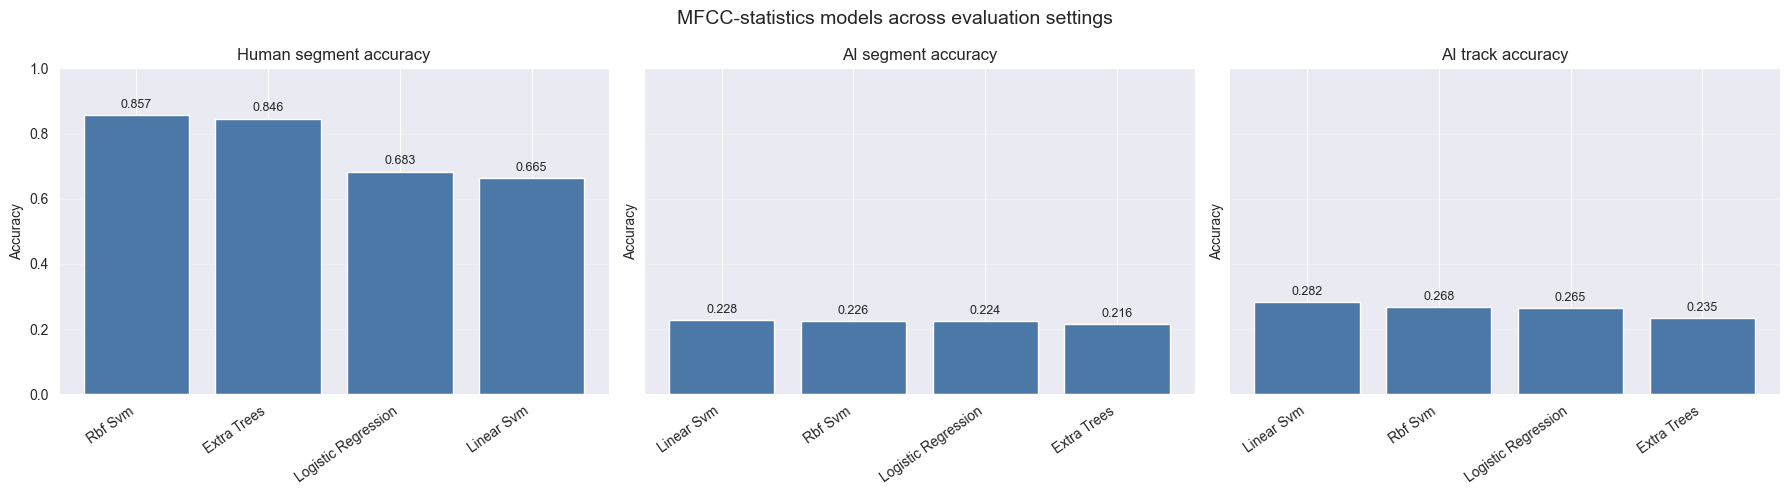

Saved MFCC model comparison plot: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/final_submission_v2/mfcc_stats_accuracy_by_method.png


In [23]:
MFCC_METHOD_COMPARISON_PNG = ARTIFACT_DIR / "mfcc_stats_accuracy_by_method.png"

method_plot_df = ml_method_df.copy()
method_plot_df["display_method"] = (
    method_plot_df["method"]
    .str.replace("_majority_vote", "", regex=False)
    .str.replace("mfcc_stats_", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

evaluation_specs = [
    ("human_segment_test", "Human segment accuracy"),
    ("ai_segment", "AI segment accuracy"),
    ("ai_track", "AI track accuracy"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (evaluation_level, title) in zip(axes, evaluation_specs):
    subset = method_plot_df[method_plot_df["evaluation_level"] == evaluation_level].sort_values("accuracy", ascending=False)
    positions = np.arange(len(subset))
    ax.bar(positions, subset["accuracy"], color="#4c78a8")
    ax.set_xticks(positions)
    ax.set_xticklabels(subset["display_method"], rotation=35, ha="right")
    apply_metric_axis_style(ax, title, "Accuracy")
    annotate_bars(ax)

fig.suptitle("MFCC-statistics models across evaluation settings", fontsize=14)
fig.tight_layout()
save_figure(fig, MFCC_METHOD_COMPARISON_PNG)
plt.show()

print("Saved MFCC model comparison plot:", MFCC_METHOD_COMPARISON_PNG)


## 7. Final Comparison

This final table preserves the same report-facing outputs as the original notebook: the human CNN baseline, the AI transfer baseline, the CNN track vote, and the strongest MFCC-statistics track-level method.


In [24]:
final_rows = [
    {
        "method": "Parent-style CNN",
        "evaluation": "GTZAN human music",
        "level": "segment",
        "accuracy": cnn_human_accuracy,
        "macro_f1": cnn_human_macro_f1,
        "items": len(y_test),
        "note": "baseline trained and tested on human music",
    },
    {
        "method": "Parent-style CNN",
        "evaluation": "Suno AI music",
        "level": "segment",
        "accuracy": cnn_ai_segment_accuracy,
        "macro_f1": cnn_ai_segment_macro_f1,
        "items": len(y_ai),
        "note": "same CNN transferred to AI music",
    },
    {
        "method": "Parent-style CNN + majority vote",
        "evaluation": "Suno AI music",
        "level": "track",
        "accuracy": cnn_ai_track_accuracy,
        "macro_f1": cnn_ai_track_macro_f1,
        "items": len(cnn_ai_track_df),
        "note": "segment predictions combined per track",
    },
]

best_ml_track = ml_method_df[ml_method_df["evaluation_level"] == "ai_track"].sort_values(
    ["accuracy", "macro_f1"],
    ascending=False,
).iloc[0]
final_rows.append(
    {
        "method": best_ml_track["method"],
        "evaluation": "Suno AI music",
        "level": "track",
        "accuracy": best_ml_track["accuracy"],
        "macro_f1": best_ml_track["macro_f1"],
        "items": int(best_ml_track["items"]),
        "note": "best final MFCC-statistics method by AI track accuracy",
    }
)

final_comparison_df = pd.DataFrame(final_rows)
final_comparison_df.to_csv(FINAL_COMPARISON_CSV, index=False)

improvement = best_ml_track["accuracy"] - cnn_ai_track_accuracy
summary_payload = {
    "project_root": str(PROJECT_ROOT),
    "human_data_root": str(HUMAN_DATA_ROOT),
    "ai_data_root": str(AI_DATA_ROOT),
    "artifact_dir": str(ARTIFACT_DIR),
    "cnn_human_accuracy": float(cnn_human_accuracy),
    "cnn_human_macro_f1": float(cnn_human_macro_f1),
    "cnn_ai_segment_accuracy": float(cnn_ai_segment_accuracy),
    "cnn_ai_segment_macro_f1": float(cnn_ai_segment_macro_f1),
    "cnn_ai_track_accuracy": float(cnn_ai_track_accuracy),
    "cnn_ai_track_macro_f1": float(cnn_ai_track_macro_f1),
    "best_final_method": str(best_ml_track["method"]),
    "best_final_ai_track_accuracy": float(best_ml_track["accuracy"]),
    "best_final_ai_track_macro_f1": float(best_ml_track["macro_f1"]),
    "accuracy_gain_over_cnn_track_baseline": float(improvement),
    "ai_tracks": int(len(cnn_ai_track_df)),
    "ai_segments": int(len(y_ai)),
    "epochs": int(EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "seed": int(SEED),
}
with open(FINAL_SUMMARY_JSON, "w") as fp:
    json.dump(summary_payload, fp, indent=2)

display(final_comparison_df)
print("Best final method:", summary_payload["best_final_method"])
print(f"AI track accuracy gain over CNN baseline: {improvement:.4f}")


,method,evaluation,level,accuracy,macro_f1,items,note
0,Parent-style CNN,GTZAN human music,segment,0.728061,0.724530,2997,baseline trained and tested on human music
1,Parent-style CNN,Suno AI music,segment,0.223154,0.195137,2980,same CNN transferred to AI music
2,Parent-style CNN + majority vote,Suno AI music,track,0.241611,0.188210,298,segment predictions combined per track
3,mfcc_stats_linear_svm_majority_vote,Suno AI music,track,0.281879,0.262316,298,best final MFCC-statistics method by AI track ...


Best final method: mfcc_stats_linear_svm_majority_vote
AI track accuracy gain over CNN baseline: 0.0403


### Visual Evidence: Final Report-Level Comparison

This plot condenses the main report table into a visual comparison of the final methods and evaluation settings.


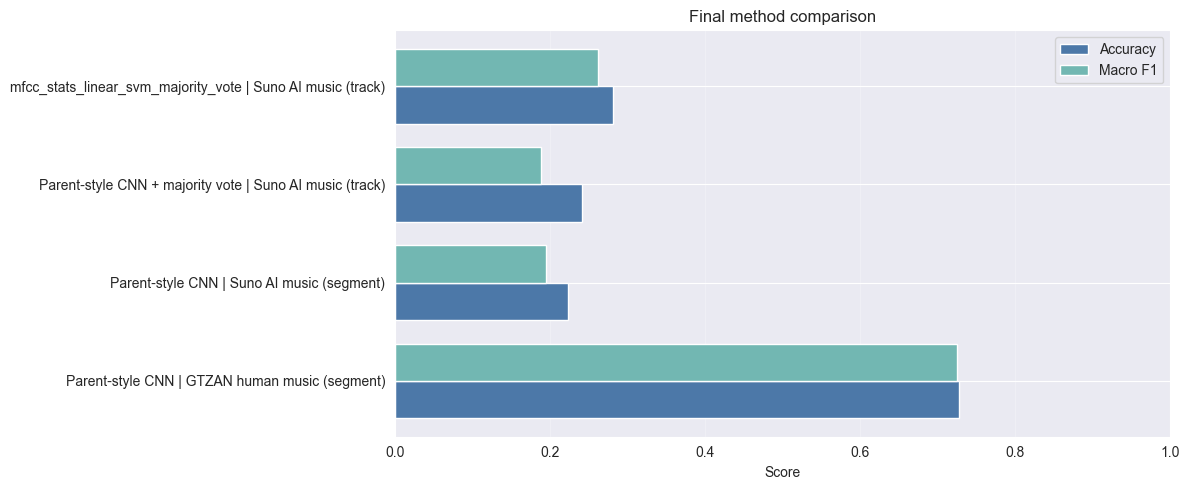

Saved final comparison plot: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/final_submission_v2/final_comparison_metrics.png


In [25]:
FINAL_COMPARISON_PNG = ARTIFACT_DIR / "final_comparison_metrics.png"

final_plot_df = final_comparison_df.copy()
final_plot_df["label"] = final_plot_df["method"] + " | " + final_plot_df["evaluation"] + " (" + final_plot_df["level"] + ")"
positions = np.arange(len(final_plot_df))
bar_height = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(positions - bar_height / 2, final_plot_df["accuracy"], height=bar_height, label="Accuracy", color="#4c78a8")
ax.barh(positions + bar_height / 2, final_plot_df["macro_f1"], height=bar_height, label="Macro F1", color="#72b7b2")
ax.set_yticks(positions)
ax.set_yticklabels(final_plot_df["label"])
ax.set_xlabel("Score")
ax.set_xlim(0, 1.0)
ax.set_title("Final method comparison")
ax.grid(axis="x", alpha=0.25)
ax.legend()
fig.tight_layout()
save_figure(fig, FINAL_COMPARISON_PNG)
plt.show()

print("Saved final comparison plot:", FINAL_COMPARISON_PNG)


## 8. Final AI Confusion Matrix

The confusion matrix below uses the best track-level MFCC-statistics method from the comparison table and saves the image to the artifact folder.


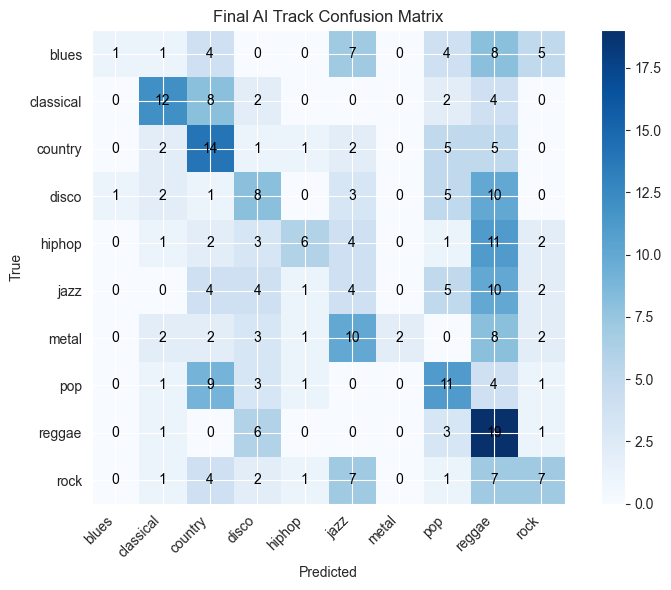

Saved final comparison: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/final_submission_v2/final_method_comparison.csv
Saved final summary: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/final_submission_v2/final_summary.json
Saved confusion matrix: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/final_submission_v2/final_ai_track_confusion_matrix.png
Saved training history: /Users/mingoosim/Desktop/DS340/Proejct/artifacts/final_submission_v2/cnn_training_history.csv


In [26]:
best_method_name = str(best_ml_track["method"]).replace("_majority_vote", "")
best_track_df = ml_track_results_df[ml_track_results_df["method"] == best_method_name].copy()

cm = confusion_matrix(
    best_track_df["true_label_id"],
    best_track_df["pred_label_id"],
    labels=list(range(len(GENRES))),
)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(GENRES)))
ax.set_yticks(range(len(GENRES)))
ax.set_xticklabels(GENRES, rotation=45, ha="right")
ax.set_yticklabels(GENRES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Final AI Track Confusion Matrix")
for i in range(len(GENRES)):
    for j in range(len(GENRES)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
fig.colorbar(im)
plt.tight_layout()
plt.savefig(AI_TRACK_CONFUSION_MATRIX_PNG, dpi=180, bbox_inches="tight")
plt.show()

print("Saved final comparison:", FINAL_COMPARISON_CSV)
print("Saved final summary:", FINAL_SUMMARY_JSON)
print("Saved confusion matrix:", AI_TRACK_CONFUSION_MATRIX_PNG)
print("Saved training history:", TRAINING_HISTORY_CSV)


## Closing Note

`final_submission_v2.ipynb` is still the same project story as the demos and the original final notebook: a human-music CNN baseline, transfer to AI music, and a stronger MFCC-statistics classical method for the final AI-track comparison. The difference is that this version is easier to rerun on another computer because the dataset inputs are explicit and the notebook is less dependent on the exact launch location.
